# Multilabel classification practice

In [1]:
! pip install -Uqq fastbook
import fastbook
fastbook.setup_book()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 719.8/719.8 kB 11.0 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.1/124.1 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 246.9/246.9 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 89.4 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 62.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 whic

In [2]:
from fastai.vision.all import *
from fastbook import *

In [3]:
def list_methods(var):
    return [a for a in dir(var) if callable(getattr(var, a))]

In [4]:
# load the data
path = untar_data(URLs.PLANET_SAMPLE)
path

<div><progress max="15523994" value="15532032"></progress> 100.05% [15532032/15523994 00:00&lt;00:00]</div>

Path('/root/.fastai/data/planet_sample')

In [5]:
Path.BASE_PATH = path
path.ls()

[Path('labels.csv'), Path('train')]

In [6]:
(path/'train').ls()

(#1000) [Path('train/train_7123.jpg'), Path('train/train_24497.jpg'), Path('train/train_29171.jpg'), Path('train/train_7073.jpg'), Path('train/train_35898.jpg'), Path('train/train_22483.jpg'), Path('train/train_5707.jpg'), Path('train/train_28038.jpg'), Path('train/train_22982.jpg'), Path('train/train_12047.jpg'), Path('train/train_20931.jpg'), Path('train/train_32971.jpg'), Path('train/train_14373.jpg'), Path('train/train_5788.jpg'), Path('train/train_14559.jpg'), Path('train/train_8871.jpg'), Path('train/train_15713.jpg'), Path('train/train_6528.jpg'), Path('train/train_22696.jpg'), Path('train/train_21680.jpg'), Path('train/train_21753.jpg'), Path('train/train_11007.jpg'), Path('train/train_8125.jpg'), Path('train/train_19234.jpg'), Path('train/train_789.jpg'), Path('train/train_14930.jpg'), Path('train/train_2989.jpg'), Path('train/train_3832.jpg'), Path('train/train_14298.jpg'), Path('train/train_30827.jpg'), Path('train/train_28430.jpg'), Path('train/train_12879.jpg'), Path('trai

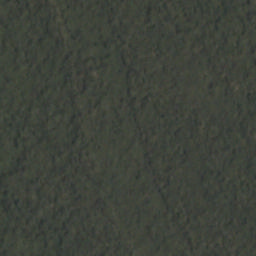

In [7]:
PILImage.create((path/'train').ls()[0])

In [8]:
# explore the data structure
df = pd.read_csv(path/'labels.csv')
df

,image_name,tags
0,train_21983,partly_cloudy primary
1,train_9516,clear cultivation primary water
2,train_12664,haze primary
3,train_36960,clear primary
4,train_5302,haze primary road
...,...,...
995,train_1876,cloudy
996,train_10311,clear primary road water
997,train_19080,clear primary
998,train_39339,clear primary road


In [9]:
# Shuffle all rows randomly
df_shuffled = df.sample(frac=1, random_state=42)

# Slice into 2 separate parts
train_df = df_shuffled.iloc[:800]
test_df = df_shuffled.iloc[800:]

In [10]:
def get_y(row):
    return row['tags'].split(' ')

def get_x(row):
    return f'{path/'train'/row['image_name']}.jpg'

In [11]:
# build up the data
dblock = DataBlock(
    blocks=(ImageBlock, MultiCategoryBlock),
    get_y=get_y,
    get_x=get_x,
    splitter=RandomSplitter(valid_pct=0.25),
)

len(dblock.datasets(train_df))

800

In [12]:
dblock.summary(train_df)

Setting-up type transforms pipelines
521   train_7574                                  clear primary
737  train_35062                                  clear primary
740  train_39244                                  clear primary
660  train_39380                                  clear primary
411  train_25104                                   haze primary
..           ...                                            ...
619   train_5286                                  clear primary
855  train_18096                                  clear primary
803  train_36771  agriculture cultivation partly_cloudy primary
645  train_28824                                  clear primary
846  train_10829                 agriculture clear primary road

[800 rows x 2 columns]
Found 800 items
2 datasets of sizes 600,200
Setting up Pipeline: get_x -> PILBase.create
Setting up Pipeline: get_y -> MultiCategorize -- {'vocab': None, 'sort': True, 'add_na': False}
 -> OneHotEncode -- {'c': None}


Building one sam

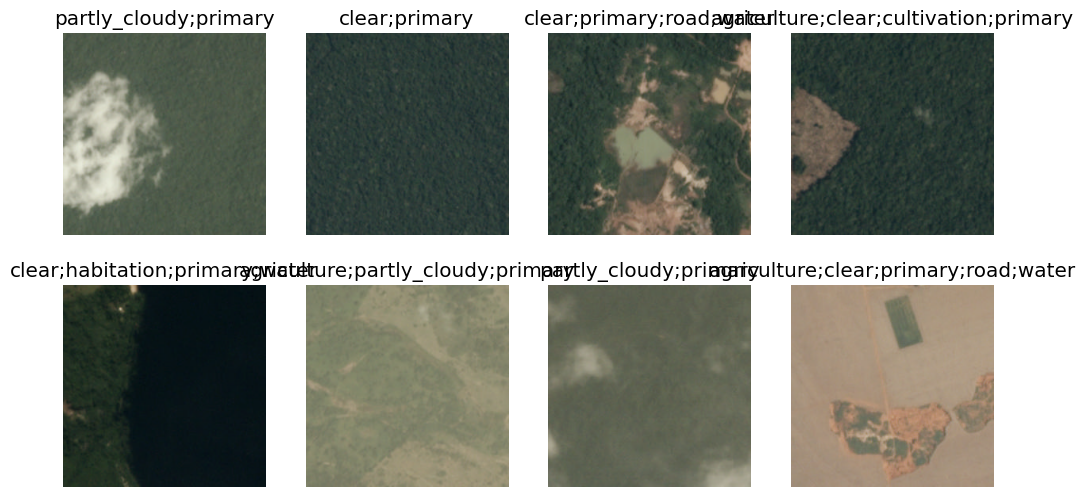

In [13]:
dls = dblock.dataloaders(train_df)
dls.show_batch(nrows=2, ncols=4)

<div></div>

SuggestedLRs(valley=0.0030199517495930195)

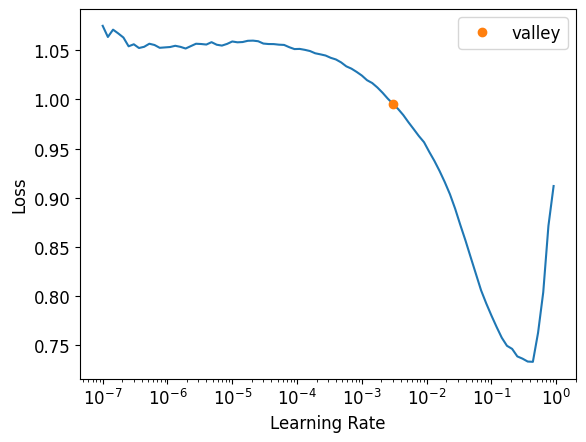

In [15]:
learn = vision_learner(dls, resnet18, metrics=accuracy_multi)
lr = learn.lr_find()
lr

In [16]:
learn.fine_tune(6, base_lr=lr.valley, freeze_epochs=3)

epoch,train_loss,valid_loss,accuracy_multi,time
0,1.021654,0.713530,0.562500,00:03
1,0.950133,0.641480,0.649688,00:02
2,0.877649,0.604448,0.695625,00:02


epoch,train_loss,valid_loss,accuracy_multi,time
0,0.659455,0.562015,0.746250,00:03
1,0.635560,0.520358,0.800625,00:03
2,0.586518,0.463286,0.836563,00:03
3,0.542774,0.435110,0.872187,00:03
4,0.499590,0.402629,0.890938,00:03
5,0.473029,0.392773,0.899375,00:03


Let's see if there's a better threshold value to use.

In [17]:
activs, targ = learn.get_preds()
activs.shape, targ.shape

(torch.Size([200, 16]), torch.Size([200, 16]))

In [19]:
activs[0],targ[0]

(tensor([0.0889, 0.2975, 0.2050, 0.2499, 0.0279, 0.1220, 0.4309, 0.3889, 0.1692, 0.5155, 0.9533, 0.8781, 0.0470, 0.3410, 0.3852, 0.4682]),
 tensor([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 0., 0., 0., 0.]))

In [23]:
import numpy as np

In [24]:
np.argmax(accs)

np.int64(19)

Max => threshold: 0.6396551728248596; accuracy: TensorBase(0.9256)


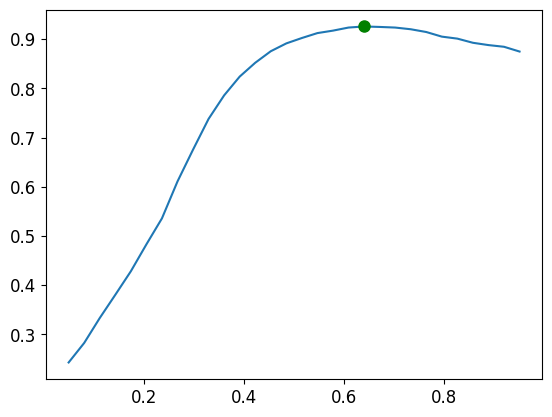

In [30]:
ts = torch.linspace(0.05, 0.95, 30)
accs = [accuracy_multi(activs, targ, thresh=t, sigmoid=False) for t in ts]

max_acc_idx = np.argmax(accs)

# plot the full curve
plt.plot(ts, accs)

# overlay the max accuracy point
max_acc_x, max_acc_y = ts[max_acc_idx], accs[max_acc_idx]
plt.plot(max_acc_x, max_acc_y, marker='o', markersize=8, color='green')

print(f'Max => threshold: {max_acc_x}; accuracy: {max_acc_y}')

Let's try training again with the newly discovered threshold.

In [31]:
learn = vision_learner(dls, resnet18, metrics=partial(accuracy_multi, thresh=max_acc_x))
learn.fine_tune(6, base_lr=lr.valley, freeze_epochs=3)

epoch,train_loss,valid_loss,accuracy_multi,time
0,1.043002,0.724887,0.709375,00:03
1,0.972318,0.681778,0.757812,00:02
2,0.885582,0.609169,0.794062,00:02


epoch,train_loss,valid_loss,accuracy_multi,time
0,0.680979,0.606470,0.816562,00:03
1,0.644301,0.556720,0.851875,00:03
2,0.603349,0.499066,0.880938,00:03
3,0.557667,0.447274,0.898438,00:03
4,0.519459,0.415728,0.915625,00:03
5,0.490691,0.412605,0.920313,00:03
